In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
from pathlib import Path
import pickle
import os

In [34]:
# ============================================================================
# CONFIGURAZIONE
# ============================================================================

class JetAnalyzer:
    """
    Classe per analizzare dati jet da file Parquet
    """
    
    def __init__(self, filepath, max_events=None):
        
        self.filepath = Path(filepath)
        self.max_events = max_events
        self.data = None
        self.variables = {
            # Variabili dei jet (array per evento)
            'jet_pt': 'FullReco_JetAK4_PT',
            'jet_eta': 'FullReco_JetAK4_Eta',
            'jet_phi': 'FullReco_JetAK4_Phi',
            'jet_mass': 'FullReco_JetAK4_Mass',
            'jet_energy': 'FullReco_JetAK4_Energy',
            'jet_n': 'FullReco_JetAK4_N',
            
            # Quantità di controllo
            'jet_constituents': 'FullReco_JetAK4_Constituents',
            'jet_btag': 'FullReco_JetAK4_BTag',
            'jet_btag_phys': 'FullReco_JetAK4_BTagPhys',
            
            # MET (opzionale)
            'met_pt': 'FullReco_MET_pt',
            'met_phi': 'FullReco_MET_phi',
            
            # Variabili evento
            'event_number': 'eventNumber',
            'run_number': 'runNumber',
        }
        
        self._load_data()
    
    def _load_data(self):
        """Carica i dati dal file Parquet"""
        print(f"Caricamento file: {self.filepath}")
        print(f"File size: {self.filepath.stat().st_size / 1024**2:.2f} MB")
        
        try:
            # Carica il file Parquet
            self.data = pd.read_parquet(self.filepath)
            print(f"✅ Caricati {len(self.data)} eventi")
            
            # Limita eventi se richiesto
            if self.max_events and self.max_events < len(self.data):
                self.data = self.data.head(self.max_events)
                print(f"   Usati {len(self.data)} eventi")
            
            # Mostra colonne disponibili
            print(f"\nColonne disponibili:")
            for col in self.data.columns:  
                print(f"  - {col}")
            
        except Exception as e:
            print(f"❌ Errore nel caricamento: {e}")
            raise
    
    def extract_jet_data(self, event_idx):
        """
        Estrae i dati dei jet per un singolo evento
        """
        event = self.data.iloc[event_idx]
        
        jet_data = {}
        for key, col_name in self.variables.items():
            if col_name in event:
                value = event[col_name]
                
                # Gestisci diversi tipi di dati
                if value is None:
                    jet_data[key] = np.array([], dtype=np.float32)
                elif isinstance(value, (list, np.ndarray)):
                    # Se è una lista, prova a convertire in array
                    try:
                        # Per costituenti: potrebbero essere liste di liste
                        if key == 'jet_constituents' and len(value) > 0:
                            # Mantieni come lista per ora, verrà gestita dopo
                            jet_data[key] = value
                        else:
                            jet_data[key] = np.array(value, dtype=np.float32)
                    except (ValueError, TypeError):
                        # Se fallisce, mantieni come lista
                        jet_data[key] = value
                else:
                    # Valore scalare
                    jet_data[key] = value
        
        return jet_data
    
    def compute_jet_parameters(self, use_leading_jets=None, min_pt=30.0):
        
        masses = []
        all_jet_pt = []
        all_jet_eta = []
        all_jet_phi = []
        all_jet_constituents = []
        all_jet_btag = []
        all_z_pt = []
        all_z_eta = []
        all_z_phi = []
        
        # Liste per leading e subleading
        leading_constituents = []
        leading_btag = []
        leading_pt = []
        leading_eta = []
        leading_phi = []
        
        subleading_constituents = []
        subleading_btag = []
        subleading_pt = []
        subleading_eta = []
        subleading_phi = []
        
        # Nuova lista per Δφ
        delta_phi_list = []
        
        print(f"\nCalcolo masse invarianti...")
        print(f"  Min PT: {min_pt} GeV")
        if use_leading_jets:
            print(f"  Usando: {use_leading_jets} leading jet")
        
        for idx in range(len(self.data)):
            jet_data = self.extract_jet_data(idx)
            
            jet_pt = jet_data['jet_pt']
            jet_eta = jet_data['jet_eta']
            jet_phi = jet_data['jet_phi']
            jet_mass = jet_data['jet_mass']
            
            # Gestisci quantità di controllo
            jet_constituents_raw = jet_data.get('jet_constituents', None)
            jet_btag = jet_data.get('jet_btag', None)
            
            # Estrai numero di costituenti
            jet_constituents = None
            if jet_constituents_raw is not None:
                try:
                    if isinstance(jet_constituents_raw, (list, np.ndarray)) and len(jet_constituents_raw) > 0:
                        if isinstance(jet_constituents_raw[0], (list, np.ndarray)):
                            jet_constituents = np.array([len(c) for c in jet_constituents_raw], dtype=np.float32)
                        else:
                            jet_constituents = np.array(jet_constituents_raw, dtype=np.float32)
                except Exception as e:
                    pass
            
            # Applica taglio pt
            mask = jet_pt > min_pt
            jet_pt = jet_pt[mask]
            jet_eta = jet_eta[mask]
            jet_phi = jet_phi[mask]
            jet_mass = jet_mass[mask]
            
            # Applica mask alle quantità di controllo
            if jet_constituents is not None and len(jet_constituents) == len(mask):
                jet_constituents = jet_constituents[mask]
            
            if jet_btag is not None and isinstance(jet_btag, (list, np.ndarray)) and len(jet_btag) == len(mask):
                try:
                    jet_btag = np.array(jet_btag, dtype=np.float32)[mask]
                except:
                    jet_btag = None
            
            if len(jet_pt) < 2:
                continue
            
            # Seleziona leading jet
            if use_leading_jets:
                # Ordina per pt decrescente
                sorted_idx = np.argsort(jet_pt)[::-1]
                jet_pt = jet_pt[sorted_idx][:use_leading_jets]
                jet_eta = jet_eta[sorted_idx][:use_leading_jets]
                jet_phi = jet_phi[sorted_idx][:use_leading_jets]
                jet_mass = jet_mass[sorted_idx][:use_leading_jets]
                
                # Salva leading e subleading properties
                leading_pt.append(jet_pt[0])
                leading_eta.append(jet_eta[0])
                leading_phi.append(jet_phi[0])
                
                if len(jet_pt) >= 2:
                    subleading_pt.append(jet_pt[1])
                    subleading_eta.append(jet_eta[1])
                    subleading_phi.append(jet_phi[1])
                    
                    # Calcola Δφ tra i due jet
                    delta_phi = jet_phi[0] - jet_phi[1]
                    # Normalizza nell'intervallo [-π, π]
                    delta_phi = np.arctan2(np.sin(delta_phi), np.cos(delta_phi))
                    delta_phi_list.append(delta_phi)
                
                # Seleziona quantità di controllo
                if jet_constituents is not None and len(jet_constituents) > 0:
                    jet_constituents_sorted = jet_constituents[sorted_idx][:use_leading_jets]
                    leading_constituents.append(float(jet_constituents_sorted[0]))
                    if len(jet_constituents_sorted) >= 2:
                        subleading_constituents.append(float(jet_constituents_sorted[1]))
                    else:
                        subleading_constituents.append(0.0)
                
                if jet_btag is not None and len(jet_btag) > 0:
                    jet_btag_sorted = jet_btag[sorted_idx][:use_leading_jets]
                    leading_btag.append(float(jet_btag_sorted[0]))
                    if len(jet_btag_sorted) >= 2:
                        subleading_btag.append(float(jet_btag_sorted[1]))
                    else:
                        subleading_btag.append(0.0)

            # Salvataggio parametri dei jet
            all_jet_pt.extend(jet_pt)
            all_jet_eta.extend(jet_eta)
            all_jet_phi.extend(jet_phi)
            
            if jet_constituents is not None and len(jet_constituents) > 0:
                all_jet_constituents.extend(jet_constituents)
            
            if jet_btag is not None and len(jet_btag) > 0:
                all_jet_btag.extend(jet_btag)

            # Calcola quadrimpulsi
            E = np.sqrt(jet_pt**2 + jet_mass**2) * np.cosh(jet_eta)
            px = jet_pt * np.cos(jet_phi)
            py = jet_pt * np.sin(jet_phi)
            pz = jet_pt * np.sinh(jet_eta)
            
            E_tot = np.sum(E)
            px_tot = np.sum(px)
            py_tot = np.sum(py)
            pz_tot = np.sum(pz)

            m2 = E_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2
            mass = np.sqrt(max(0, m2))
            masses.append(mass)

            z_pt = np.sqrt(px_tot**2 + py_tot**2)
            
            if E_tot > abs(pz_tot):
                z_eta = 0.5 * np.log((E_tot + pz_tot) / (E_tot - pz_tot))
            else:
                z_eta = 0.0
            
            z_phi = np.arctan2(py_tot, px_tot)
            
            all_z_pt.append(z_pt)
            all_z_eta.append(z_eta)
            all_z_phi.append(z_phi)
            
            if (idx + 1) % 1000 == 0:
                print(f"  Processati {idx + 1}/{len(self.data)} eventi")
        
        # Converti liste in array numpy
        masses = np.array(masses)
        all_jet_pt = np.array(all_jet_pt)
        all_jet_eta = np.array(all_jet_eta)
        all_jet_phi = np.array(all_jet_phi)
        all_z_pt = np.array(all_z_pt)
        all_z_eta = np.array(all_z_eta)
        all_z_phi = np.array(all_z_phi)
        
        leading_pt = np.array(leading_pt) if leading_pt else None
        leading_eta = np.array(leading_eta) if leading_eta else None
        leading_phi = np.array(leading_phi) if leading_phi else None
        subleading_pt = np.array(subleading_pt) if subleading_pt else None
        subleading_eta = np.array(subleading_eta) if subleading_eta else None
        subleading_phi = np.array(subleading_phi) if subleading_phi else None
        delta_phi = np.array(delta_phi_list) if delta_phi_list else None
        
        all_jet_constituents = np.array(all_jet_constituents, dtype=np.float32) if all_jet_constituents else None
        all_jet_btag = np.array(all_jet_btag, dtype=np.float32) if all_jet_btag else None
        leading_constituents = np.array(leading_constituents, dtype=np.float32) if leading_constituents else None
        leading_btag = np.array(leading_btag, dtype=np.float32) if leading_btag else None
        subleading_constituents = np.array(subleading_constituents, dtype=np.float32) if subleading_constituents else None
        subleading_btag = np.array(subleading_btag, dtype=np.float32) if subleading_btag else None
        
        return (masses, all_jet_pt, all_jet_eta, all_jet_phi, 
                all_z_pt, all_z_eta, all_z_phi,
                all_jet_constituents, all_jet_btag,
                leading_constituents, leading_btag,
                subleading_constituents, subleading_btag,
                leading_pt, leading_eta, leading_phi,
                subleading_pt, subleading_eta, subleading_phi,
                delta_phi)

In [35]:
# ============================================================================
# FUNZIONE DI PLOTTING
# ============================================================================

def plot_distribution(data, 
                      title="Distribution", 
                      xlabel="Value", 
                      ylabel="Events",
                      bins=100, 
                      range_min=None, 
                      range_max=None,
                      log_scale=False,
                      add_z_line=False,
                      z_mass=91.1876,
                      add_zoom=False,
                      zoom_range=(50, 150),
                      zoom_bins=50,
                      add_band=False,
                      band_width=2.5,
                      color='blue',
                      edgecolor='black',
                      alpha=0.7,
                      histtype='stepfilled',
                      save_path=None,
                      show_plot=True,
                      figsize=(6, 5)):
    """
    Funzione unificata per plottare distribuzioni con varie opzioni.
    """
    
    # Converti data in numpy array se non lo è già
    data = np.asarray(data)

    # Appiattisci l'array se ha più di una dimensione
    if data.ndim > 1:
        data = data.flatten()

    # Filtra dati se necessario
    if range_min is not None or range_max is not None:
        mask = np.ones(len(data), dtype=bool)
        if range_min is not None:
            mask &= data >= range_min
        if range_max is not None:
            mask &= data <= range_max
        plot_data = data[mask]
    else:
        plot_data = data
    
    # Determina se fare zoom
    if add_zoom:
        # Due subplot: uno normale e uno zoom
        fig, axes = plt.subplots(1, 2, figsize=(figsize[0]*2, figsize[1]))
        ax1 = axes[0]
        ax2 = axes[1]
    else:
        # Un solo subplot
        fig, ax1 = plt.subplots(figsize=(figsize[0], figsize[1]))
        ax2 = None
    
    # Plot principale
    ax1.hist(plot_data, bins=bins, range=(range_min, range_max) if range_min is not None else None,
             edgecolor=edgecolor, alpha=alpha, histtype=histtype, color=color)
    
    # Aggiungi linea Z se richiesto
    if add_z_line:
        ax1.axvline(x=z_mass, color='red', linestyle='--', linewidth=2, 
                    label=f'Z boson ({z_mass:.1f} GeV)')
        
        # Aggiungi banda se richiesto
        if add_band:
            ax1.axvspan(z_mass - band_width, z_mass + band_width, 
                        alpha=0.2, color='red', label=f'Z width region')
    
    # Configurazione assi principali
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    
    # Aggiungi titolo con informazioni su scala
    if log_scale:
        ax1.set_yscale('log')
        main_title = f"{title} (log scale)"
    else:
        main_title = f"{title} (linear)"
    
    ax1.set_title(main_title)
    ax1.grid(True, alpha=0.3)
    
    if add_z_line:
        ax1.legend()
    
    # Plot zoom se richiesto
    if add_zoom:
        # Filtra dati per lo zoom
        zoom_mask = (data >= zoom_range[0]) & (data <= zoom_range[1])
        zoom_data = data[zoom_mask]
        
        # Istogramma zoom
        ax2.hist(zoom_data, bins=zoom_bins, range=zoom_range,
                 edgecolor=edgecolor, alpha=alpha, histtype=histtype, color=color)
        
        # Aggiungi linea Z e banda se richiesto
        if add_z_line:
            ax2.axvline(x=z_mass, color='red', linestyle='--', linewidth=2, 
                        label=f'Z boson ({z_mass:.1f} GeV)')
            if add_band:
                ax2.axvspan(z_mass - band_width, z_mass + band_width, 
                            alpha=0.2, color='red', label='Z width region')
        
        ax2.set_xlabel(xlabel)
        ax2.set_ylabel(ylabel)
        ax2.set_title(f"{title} (zoom on {zoom_range[0]}-{zoom_range[1]} GeV)")
        ax2.grid(True, alpha=0.3)
        
        if add_z_line:
            ax2.legend()
    
    plt.tight_layout()
    
    # Salva se richiesto
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot salvato in {save_path}")
    
    # Mostra se richiesto
    if show_plot:
        plt.show()
    
    return fig, ax1 if not add_zoom else (fig, axes)


def plot_3_distributions(data1, data2, data3, 
                        particle="Z",
                        bins=[100, 100, 50],
                        ranges=[(0, 200), (-5, 5), (-np.pi, np.pi)],
                        xlabels=["pT [GeV]", 'η', 'φ [rad]'],
                        color='steelblue',
                        edgecolor='black',
                        alpha=0.7,
                        save_path=None,
                        show_plot=True,
                        figsize=(18, 5)):
    """
    Plotta 3 distribuzioni con range separati per ogni variabile.
    """
    
    data_list = [data1, data2, data3]
    plot_data = []
    
    # Processa i dati
    for i in range(3):
        data = np.asarray(data_list[i]).flatten()
        data = data[~np.isnan(data)]
        data = data[~np.isinf(data)]
        
        # Applica range specifico
        if ranges[i] is not None:
            data = data[(data >= ranges[i][0]) & (data <= ranges[i][1])]
        
        plot_data.append(data)
    
    # Crea figura
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Titoli
    base_titles = ['pT Distribution', 'η Distribution', 'φ Distribution']
    titles = [f"{particle} {title}" for title in base_titles]
    
    # Plot
    for i in range(3):
        axes[i].hist(plot_data[i], bins=bins[i] if isinstance(bins, list) else bins,
                     range=ranges[i] if ranges[i] is not None else None,
                     edgecolor=edgecolor, alpha=alpha, 
                     color=color, histtype='stepfilled')
        axes[i].set_xlabel(xlabels[i])
        axes[i].set_ylabel("Counts")
        axes[i].set_title(titles[i])
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot salvato in {save_path}")
    
    if show_plot:
        plt.show()
    
    return fig, axes

In [36]:
# ============================================================================
# FUNZIONE PRINCIPALE
# ============================================================================

# Configurazione
DATA_FILE = "data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet"
OUTPUT_DIR = "plots"
    
# Crea directory per i plot
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    
print("="*60)
print("ANALISI DATI JET")
print("="*60)
    
# Inizializza analizzatore e estrazione parametri
analyzer = JetAnalyzer(DATA_FILE, max_events=None)  # None per tutti gli eventi
# Chiamata alla funzione con i nuovi returns
(masses, jet_pt, jet_eta, jet_phi, 
 z_pt, z_eta, z_phi,
 constituents, btag,
 leading_const, leading_btag,
 subleading_const, subleading_btag,
 leading_pt, leading_eta, leading_phi,
 subleading_pt, subleading_eta, subleading_phi,
 delta_phi) = analyzer.compute_jet_parameters(use_leading_jets=2, min_pt=30)



ANALISI DATI JET
Caricamento file: data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet
File size: 1449.62 MB
✅ Caricati 9972 eventi

Colonne disponibili:
  - FullReco_PFCand_PT
  - FullReco_PFCand_Eta
  - FullReco_PFCand_Phi
  - FullReco_PFCand_PID
  - FullReco_PFCand_Charge
  - FullReco_PFCand_Mass
  - FullReco_PFCand_D0
  - FullReco_PFCand_DZ
  - FullReco_PFCand_ErrorD0
  - FullReco_PFCand_ErrorDZ
  - FullReco_PFCand_fUniqueID
  - FullReco_PFCand_PuppiW
  - FullReco_PUPPIPart_PT
  - FullReco_PUPPIPart_Eta
  - FullReco_PUPPIPart_Phi
  - FullReco_PUPPIPart_Charge
  - FullReco_PUPPIPart_Mass
  - FullReco_PUPPIPart_PID
  - FullReco_PUPPIPart_D0
  - FullReco_PUPPIPart_DZ
  - FullReco_PUPPIPart_ErrorD0
  - FullReco_PUPPIPart_ErrorDZ
  - FullReco_PUPPIPart_fUniqueID
  - FullReco_PUPPIPart_PuppiW
  - FullReco_Electron_PT
  - FullReco_Electron_Eta
  - FullReco_Electron_Phi
  - FullReco_Electron_EhadOverEem
  - FullReco_Electron_IsolationVarRhoCorr
  - FullReco_MuonTight_PT


1. MASSA (LEADING 2 JET)
Eventi: 5218
Massa media: 232.86 GeV
Massa mediana: 152.92 GeV
✅ Plot salvato in plots/mass.png


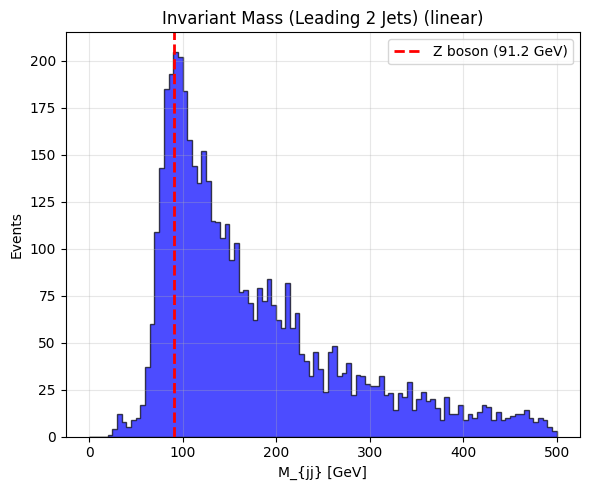


2. DISTRIBUZIONI DEI LEADING 2 JET
Jet totali: 10436
✅ Plot salvato in plots/jet_distributions.png


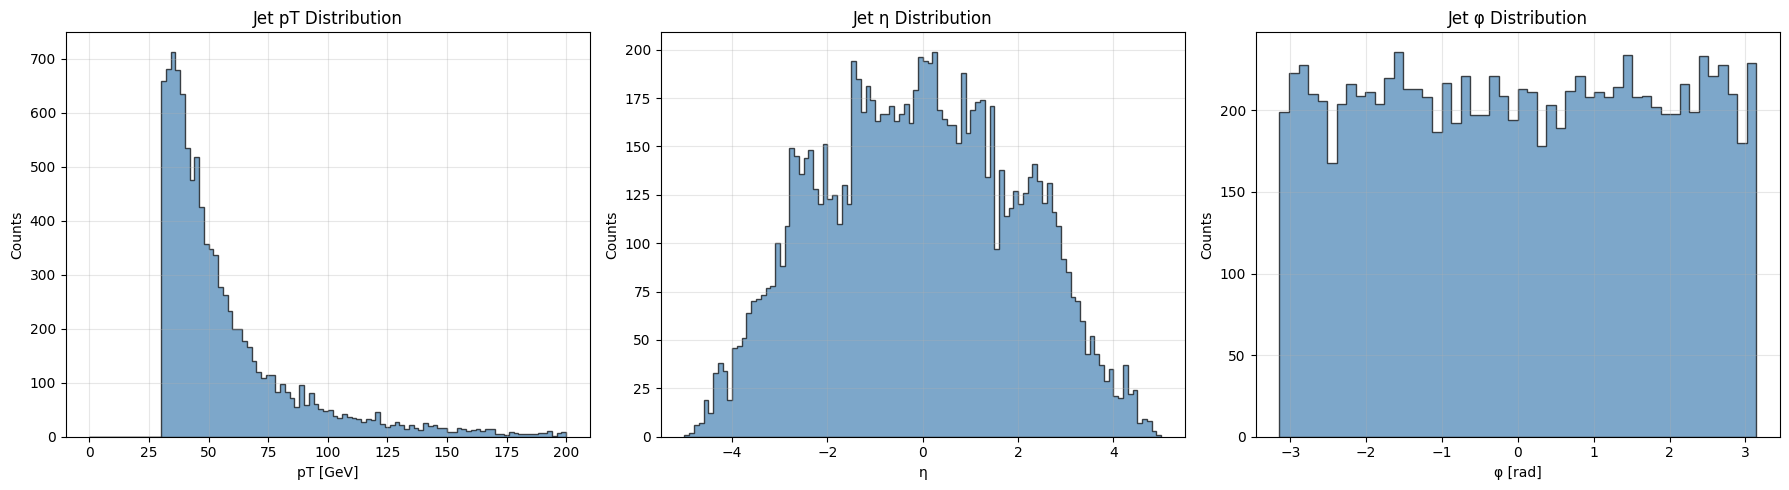


3. DISTRIBUZIONI DEI Z (LEADING 2 JET)
✅ Plot salvato in plots/z_distributions.png


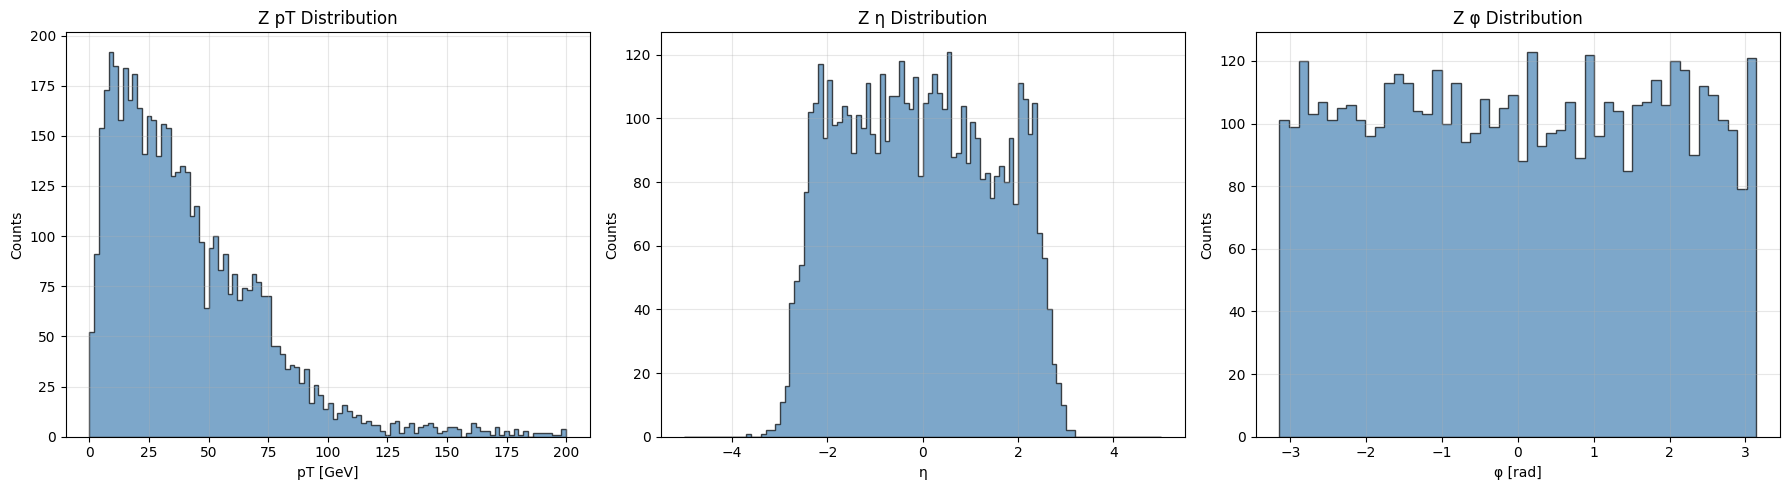


ANALISI COMPLETATA!
Plot salvati in: plots/


In [37]:
# 1. Plotta massa (leading 2 jet)
print("\n" + "="*60)
print("1. MASSA (LEADING 2 JET)")
print("="*60)
    
print(f"Eventi: {len(masses)}")
print(f"Massa media: {np.mean(masses):.2f} GeV")
print(f"Massa mediana: {np.median(masses):.2f} GeV")
    
plot_distribution(
    masses,
    title="Invariant Mass (Leading 2 Jets)",
    xlabel="M_{jj} [GeV]",
    ylabel="Events",
    bins=100,
    range_min=0,
    range_max=500,
    add_z_line=True,
    save_path=f"{OUTPUT_DIR}/mass.png"
)

# 2. Plotta distribuzioni pt eta e phi dei jet (leading 2 jet)
print("\n" + "="*60)
print("2. DISTRIBUZIONI DEI LEADING 2 JET")
print("="*60)

print(f"Jet totali: {len(jet_pt)}")
    
plot_3_distributions(
    jet_pt, jet_eta, jet_phi,
    particle="Jet",
    save_path=f"{OUTPUT_DIR}/jet_distributions.png"
)
    
# 3. Plotta distribuzioni pt eta e phi dei Z (leading 2 jet)
print("\n" + "="*60)
print("3. DISTRIBUZIONI DEI Z (LEADING 2 JET)")
print("="*60)
    
plot_3_distributions(
    z_pt, z_eta, z_phi,
    particle="Z",
    save_path=f"{OUTPUT_DIR}/z_distributions.png"
)
    
# Fine
print("\n" + "="*60)
print("ANALISI COMPLETATA!")
print("="*60)
print(f"Plot salvati in: {OUTPUT_DIR}/")


QUANTITÀ DI CONTROLLO - STATISTICHE

Jet Multiplicity:
  Eventi con ≥1 jet: 8034
  Eventi con ≥2 jet: 5218
  Media jet/evento: 1.73

Costituenti (tutti i jet):
  Media: 44.9
  Mediana: 37.0
  Range: [6, 151]

B-tagging (tutti i jet):
  Media: 0.017
  Mediana: 0.000
  Jet con score > 0.5: 301 (1.7%)

QUANTITÀ DI CONTROLLO - STATISTICHE

Jet Multiplicity:
  Eventi con ≥1 jet: 8034
  Eventi con ≥2 jet: 5218
  Media jet/evento: 1.73

Costituenti (tutti i jet):
  Media: 44.9
  Mediana: 37.0
  Range: [6, 151]

B-tagging (tutti i jet):
  Media: 0.017
  Mediana: 0.000
  Jet con score > 0.5: 301 (1.7%)
✅ Plot salvato in plots/control_quantities.png


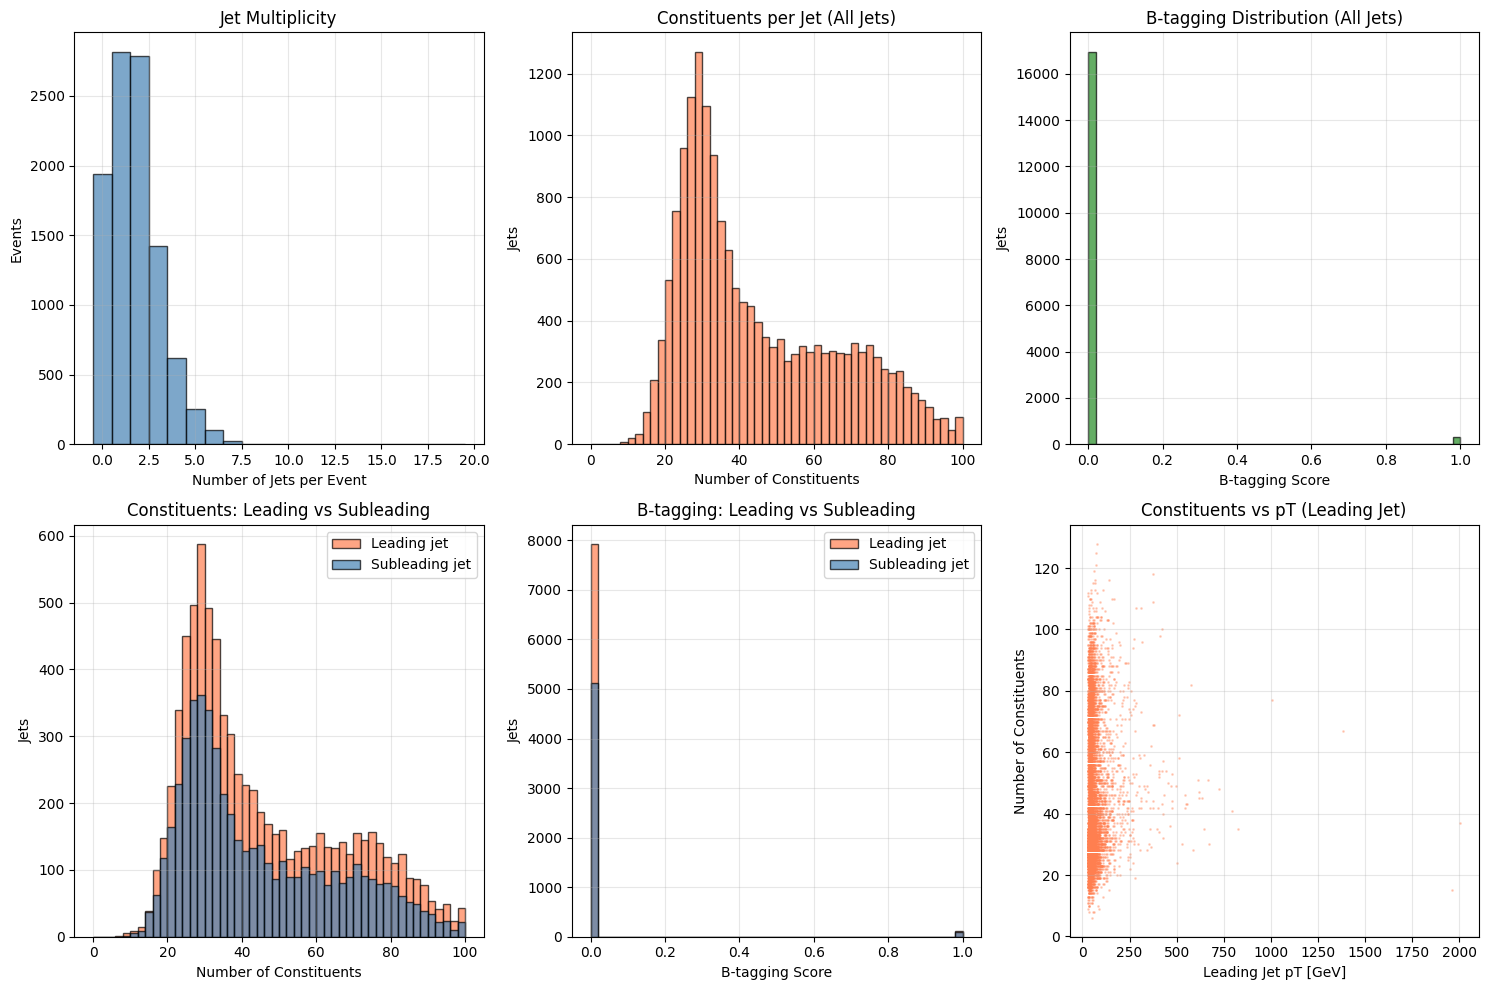

(<Figure size 1500x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'Jet Multiplicity'}, xlabel='Number of Jets per Event', ylabel='Events'>,
         <Axes: title={'center': 'Constituents per Jet (All Jets)'}, xlabel='Number of Constituents', ylabel='Jets'>,
         <Axes: title={'center': 'B-tagging Distribution (All Jets)'}, xlabel='B-tagging Score', ylabel='Jets'>],
        [<Axes: title={'center': 'Constituents: Leading vs Subleading'}, xlabel='Number of Constituents', ylabel='Jets'>,
         <Axes: title={'center': 'B-tagging: Leading vs Subleading'}, xlabel='B-tagging Score', ylabel='Jets'>,
         <Axes: title={'center': 'Constituents vs pT (Leading Jet)'}, xlabel='Leading Jet pT [GeV]', ylabel='Number of Constituents'>]],
       dtype=object))

In [38]:
# ============================================================================
# FUNZIONE PLOT_CONTROL_QUANTITIES CORRETTA
# ============================================================================

def plot_control_quantities(analyzer, min_pt=30.0, save_path=None, show_plot=True):
    """
    Plotta quantità di controllo per i jet (costituenti, tracce, etc.)
    """
    
    # Estrai dati
    control_data = extract_control_quantities(analyzer, min_pt=min_pt)
    
    # Crea figura con subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Jet multiplicity
    if control_data['jet_multiplicity'] is not None:
        axes[0,0].hist(control_data['jet_multiplicity'], bins=range(0, 21), align='left',
                       edgecolor='black', alpha=0.7, color='steelblue')
        axes[0,0].set_xlabel('Number of Jets per Event')
        axes[0,0].set_ylabel('Events')
        axes[0,0].set_title('Jet Multiplicity')
        axes[0,0].grid(True, alpha=0.3)
    
    # 2. Numero di costituenti (tutti i jet) - assicurati che sia 1D
    if control_data['all_constituents'] is not None:
        constituents = np.asarray(control_data['all_constituents']).flatten()
        if len(constituents) > 0:
            axes[0,1].hist(constituents, bins=50, range=(0, 100),
                           edgecolor='black', alpha=0.7, color='coral')
            axes[0,1].set_xlabel('Number of Constituents')
            axes[0,1].set_ylabel('Jets')
            axes[0,1].set_title('Constituents per Jet (All Jets)')
            axes[0,1].grid(True, alpha=0.3)
        else:
            axes[0,1].text(0.5, 0.5, 'No constituent data available', 
                           transform=axes[0,1].transAxes, ha='center', va='center')
            axes[0,1].set_title('Constituents (Not Available)')
    else:
        axes[0,1].text(0.5, 0.5, 'No constituent data available', 
                       transform=axes[0,1].transAxes, ha='center', va='center')
        axes[0,1].set_title('Constituents (Not Available)')
    
    # 3. B-tagging (tutti i jet) - assicurati che sia 1D
    if control_data['all_btag'] is not None:
        btag = np.asarray(control_data['all_btag']).flatten()
        if len(btag) > 0:
            axes[0,2].hist(btag, bins=50, range=(0, 1),
                           edgecolor='black', alpha=0.7, color='forestgreen')
            axes[0,2].set_xlabel('B-tagging Score')
            axes[0,2].set_ylabel('Jets')
            axes[0,2].set_title('B-tagging Distribution (All Jets)')
            axes[0,2].grid(True, alpha=0.3)
        else:
            axes[0,2].text(0.5, 0.5, 'No b-tagging data available', 
                           transform=axes[0,2].transAxes, ha='center', va='center')
            axes[0,2].set_title('B-tagging (Not Available)')
    else:
        axes[0,2].text(0.5, 0.5, 'No b-tagging data available', 
                       transform=axes[0,2].transAxes, ha='center', va='center')
        axes[0,2].set_title('B-tagging (Not Available)')
    
    # 4. Costituenti leading vs subleading
    if control_data['leading_constituents'] is not None and control_data['subleading_constituents'] is not None:
        leading = np.asarray(control_data['leading_constituents']).flatten()
        subleading = np.asarray(control_data['subleading_constituents']).flatten()
        
        if len(leading) > 0 and len(subleading) > 0:
            axes[1,0].hist(leading, bins=50, range=(0, 100),
                           alpha=0.7, label='Leading jet', color='coral', edgecolor='black')
            axes[1,0].hist(subleading, bins=50, range=(0, 100),
                           alpha=0.7, label='Subleading jet', color='steelblue', edgecolor='black')
            axes[1,0].set_xlabel('Number of Constituents')
            axes[1,0].set_ylabel('Jets')
            axes[1,0].set_title('Constituents: Leading vs Subleading')
            axes[1,0].legend()
            axes[1,0].grid(True, alpha=0.3)
        else:
            axes[1,0].text(0.5, 0.5, 'No constituent data available', 
                           transform=axes[1,0].transAxes, ha='center', va='center')
            axes[1,0].set_title('Constituents Comparison (Not Available)')
    
    # 5. B-tagging leading vs subleading
    if control_data['leading_btag'] is not None and control_data['subleading_btag'] is not None:
        leading_btag = np.asarray(control_data['leading_btag']).flatten()
        subleading_btag = np.asarray(control_data['subleading_btag']).flatten()
        
        if len(leading_btag) > 0 and len(subleading_btag) > 0:
            axes[1,1].hist(leading_btag, bins=50, range=(0, 1),
                           alpha=0.7, label='Leading jet', color='coral', edgecolor='black')
            axes[1,1].hist(subleading_btag, bins=50, range=(0, 1),
                           alpha=0.7, label='Subleading jet', color='steelblue', edgecolor='black')
            axes[1,1].set_xlabel('B-tagging Score')
            axes[1,1].set_ylabel('Jets')
            axes[1,1].set_title('B-tagging: Leading vs Subleading')
            axes[1,1].legend()
            axes[1,1].grid(True, alpha=0.3)
        else:
            axes[1,1].text(0.5, 0.5, 'No b-tagging data available', 
                           transform=axes[1,1].transAxes, ha='center', va='center')
            axes[1,1].set_title('B-tagging Comparison (Not Available)')
    
    # 6. Correlazione costituenti vs pT
    if control_data['leading_constituents'] is not None and control_data['leading_pt'] is not None:
        leading_pt = np.asarray(control_data['leading_pt']).flatten()
        leading_const = np.asarray(control_data['leading_constituents']).flatten()
        
        # Assicurati che abbiano la stessa lunghezza
        min_len = min(len(leading_pt), len(leading_const))
        if min_len > 0:
            axes[1,2].scatter(leading_pt[:min_len], leading_const[:min_len],
                              alpha=0.3, s=1, c='coral')
            axes[1,2].set_xlabel('Leading Jet pT [GeV]')
            axes[1,2].set_ylabel('Number of Constituents')
            axes[1,2].set_title('Constituents vs pT (Leading Jet)')
            axes[1,2].grid(True, alpha=0.3)
        else:
            axes[1,2].text(0.5, 0.5, 'No correlation data available', 
                           transform=axes[1,2].transAxes, ha='center', va='center')
            axes[1,2].set_title('Correlation (Not Available)')
    else:
        axes[1,2].text(0.5, 0.5, 'No correlation data available', 
                       transform=axes[1,2].transAxes, ha='center', va='center')
        axes[1,2].set_title('Correlation (Not Available)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot salvato in {save_path}")
    
    if show_plot:
        plt.show()
    
    return fig, axes


# ============================================================================
# FUNZIONE EXTRACT_CONTROL_QUANTITIES CORRETTA
# ============================================================================

def extract_control_quantities(analyzer, min_pt=30.0):
    """
    Estrae quantità di controllo dai jet (costituenti, b-tagging, etc.)
    """
    
    # Inizializza liste
    jet_multiplicity = []
    
    all_constituents = []
    all_btag = []
    
    leading_constituents = []
    leading_btag = []
    leading_pt = []
    
    subleading_constituents = []
    subleading_btag = []
    subleading_pt = []
    
    for idx in range(len(analyzer.data)):
        jet_data = analyzer.extract_jet_data(idx)
        
        # Dati dei jet
        jet_pt = np.array(jet_data['jet_pt'], dtype=np.float32)
        jet_eta = np.array(jet_data['jet_eta'], dtype=np.float32)
        
        # Quantità di controllo
        jet_constituents_raw = jet_data.get('jet_constituents', None)
        jet_btag = jet_data.get('jet_btag', None)
        
        # Applica taglio pt
        mask = jet_pt > min_pt
        jet_pt = jet_pt[mask]
        jet_eta = jet_eta[mask]
        
        # Salva jet multiplicity
        jet_multiplicity.append(len(jet_pt))
        
        # Processa costituenti (prendi la lunghezza se è una lista di liste)
        if jet_constituents_raw is not None:
            try:
                if isinstance(jet_constituents_raw, (list, np.ndarray)):
                    if len(jet_constituents_raw) > 0:
                        # Se il primo elemento è una lista, prendi la lunghezza
                        if isinstance(jet_constituents_raw[0], (list, np.ndarray)):
                            constituents_counts = np.array([len(c) for c in jet_constituents_raw], dtype=np.float32)
                        else:
                            # Altrimenti è già una lista di numeri
                            constituents_counts = np.array(jet_constituents_raw, dtype=np.float32)
                        
                        # Applica mask
                        constituents_counts = constituents_counts[mask]
                        all_constituents.extend(constituents_counts)
            except Exception as e:
                pass
        
        # Processa b-tagging
        if jet_btag is not None:
            try:
                if isinstance(jet_btag, (list, np.ndarray)):
                    jet_btag = np.array(jet_btag, dtype=np.float32)[mask]
                    all_btag.extend(jet_btag)
            except Exception as e:
                pass
        
        # Estrai leading jet
        if len(jet_pt) >= 1:
            sorted_idx = np.argsort(jet_pt)[::-1]
            leading_pt.append(jet_pt[sorted_idx[0]])
            
            # Leading constituents
            if 'constituents_counts' in locals() and len(constituents_counts) > sorted_idx[0]:
                leading_constituents.append(constituents_counts[sorted_idx[0]])
            
            # Leading btag
            if jet_btag is not None and len(jet_btag) > sorted_idx[0]:
                leading_btag.append(jet_btag[sorted_idx[0]])
            
            # Subleading jet
            if len(jet_pt) >= 2:
                subleading_pt.append(jet_pt[sorted_idx[1]])
                
                if 'constituents_counts' in locals() and len(constituents_counts) > sorted_idx[1]:
                    subleading_constituents.append(constituents_counts[sorted_idx[1]])
                
                if jet_btag is not None and len(jet_btag) > sorted_idx[1]:
                    subleading_btag.append(jet_btag[sorted_idx[1]])
    
    # Converti in array numpy e appiattisci
    results = {
        'jet_multiplicity': np.array(jet_multiplicity).flatten() if jet_multiplicity else None,
        'all_constituents': np.array(all_constituents).flatten() if all_constituents else None,
        'all_btag': np.array(all_btag).flatten() if all_btag else None,
        'leading_pt': np.array(leading_pt).flatten() if leading_pt else None,
        'leading_constituents': np.array(leading_constituents).flatten() if leading_constituents else None,
        'leading_btag': np.array(leading_btag).flatten() if leading_btag else None,
        'subleading_pt': np.array(subleading_pt).flatten() if subleading_pt else None,
        'subleading_constituents': np.array(subleading_constituents).flatten() if subleading_constituents else None,
        'subleading_btag': np.array(subleading_btag).flatten() if subleading_btag else None,
    }
    
    # Stampa statistiche
    print("\n" + "="*60)
    print("QUANTITÀ DI CONTROLLO - STATISTICHE")
    print("="*60)
    
    if results['jet_multiplicity'] is not None:
        print(f"\nJet Multiplicity:")
        print(f"  Eventi con ≥1 jet: {np.sum(results['jet_multiplicity'] >= 1)}")
        print(f"  Eventi con ≥2 jet: {np.sum(results['jet_multiplicity'] >= 2)}")
        print(f"  Media jet/evento: {np.mean(results['jet_multiplicity']):.2f}")
    
    if results['all_constituents'] is not None and len(results['all_constituents']) > 0:
        print(f"\nCostituenti (tutti i jet):")
        print(f"  Media: {np.mean(results['all_constituents']):.1f}")
        print(f"  Mediana: {np.median(results['all_constituents']):.1f}")
        print(f"  Range: [{np.min(results['all_constituents']):.0f}, {np.max(results['all_constituents']):.0f}]")
    
    if results['all_btag'] is not None and len(results['all_btag']) > 0:
        print(f"\nB-tagging (tutti i jet):")
        print(f"  Media: {np.mean(results['all_btag']):.3f}")
        print(f"  Mediana: {np.median(results['all_btag']):.3f}")
        print(f"  Jet con score > 0.5: {np.sum(results['all_btag'] > 0.5)} ({100*np.sum(results['all_btag'] > 0.5)/len(results['all_btag']):.1f}%)")
    
    return results


# ============================================================================
# UTILIZZO
# ============================================================================


# Plotta quantità di controllo
control_data = extract_control_quantities(analyzer, min_pt=30)
plot_control_quantities(analyzer, min_pt=30, save_path="plots/control_quantities.png")


ANALISI Δφ TRA I DUE JET LEADING
Δφ medio: 0.019 rad
Δφ mediano: 0.160 rad
Δφ RMS: 2.558 rad
Eventi con Δφ > 2.5 rad (back-to-back): 1637 (31.4%)
✅ Plot salvato in plots/delta_phi_distribution.png


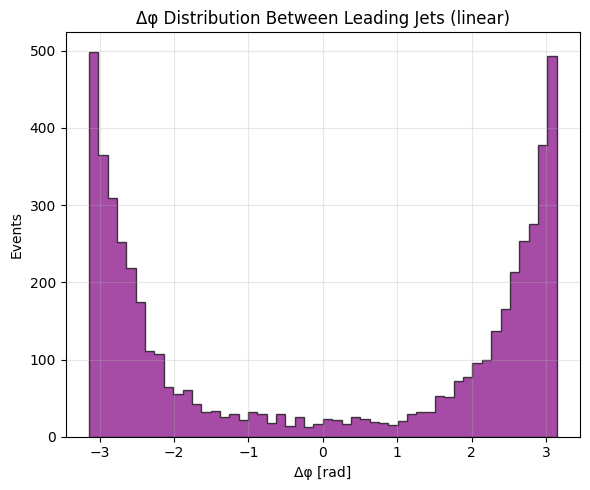

In [44]:
# Plot Δφ tra i due jet
if delta_phi is not None and len(delta_phi) > 0:
    print("\n" + "="*60)
    print("ANALISI Δφ TRA I DUE JET LEADING")
    print("="*60)
    
    print(f"Δφ medio: {np.mean(delta_phi):.3f} rad")
    print(f"Δφ mediano: {np.median(delta_phi):.3f} rad")
    print(f"Δφ RMS: {np.std(delta_phi):.3f} rad")
    print(f"Eventi con Δφ > 2.5 rad (back-to-back): {np.sum(delta_phi > 2.5)} ({100*np.sum(delta_phi > 2.5)/len(delta_phi):.1f}%)")
    
    # Plot usando la funzione plot_distribution
    plot_distribution(
        delta_phi,
        title="Δφ Distribution Between Leading Jets",
        xlabel="Δφ [rad]",
        ylabel="Events",
        bins=50,
        range_min=-np.pi,
        range_max=np.pi,
        color='purple',
        save_path=f"{OUTPUT_DIR}/delta_phi_distribution.png"
    )